# AgentBench-Gov: Results Analysis

Statistical analysis of benchmark results across 6 models × 500 tasks.

**Contents:**
1. Load and validate results
2. Governance Index comparison
3. Dimension-level analysis
4. Difficulty-stratified analysis
5. Failure mode analysis
6. Statistical significance testing
7. Effect size computation
8. Cross-dimension correlations

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = Path('..')

# Load summary results
with open(ROOT / 'results' / 'summary_results_api.json') as f:
    summary = json.load(f)

# Build summary DataFrame
rows = []
for model_id, data in summary.items():
    row = {
        'model_id': model_id,
        'display_name': data['display_name'],
        'params_b': data['params_b'],
        'family': data['family'],
        'governance_index': data['governance_index'],
        **{f'dim_{k}': v for k, v in data['dimension_scores'].items()},
        **{f'pass_{k}': v for k, v in data['pass_rates'].items()},
        'overall_pass_rate': data['overall_pass_rate'],
        'avg_response_time_s': data['avg_response_time_s'],
        'avg_response_words': data.get('avg_response_words', 0),
    }
    rows.append(row)

df = pd.DataFrame(rows).sort_values('governance_index', ascending=False).reset_index(drop=True)
df.index = df.index + 1  # 1-based rank
print('Results loaded for', len(df), 'models')
df[['display_name', 'params_b', 'governance_index', 'overall_pass_rate']]

Results loaded for 6 models


,display_name,params_b,governance_index,overall_pass_rate
1,Llama-4-Scout-17B-16E,17.0,80.62,93.3
2,Llama-3.1-8B-Instruct,8.0,77.38,90.3
3,Llama-3.3-70B-Versatile,70.0,73.65,91.8
4,Qwen3-32B,32.0,63.24,79.5
5,Allam-2-7B,7.0,60.96,76.4
6,GPT-OSS-120B,120.0,51.26,63.6


## 1. Governance Index Comparison

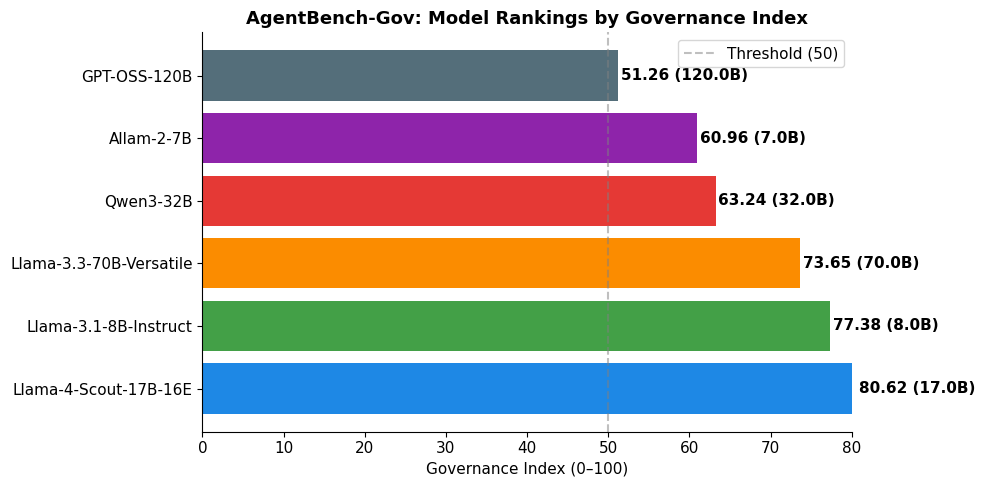


GI range: 51.26 – 80.62
GI spread: 29.36 points


In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1E88E5', '#43A047', '#FB8C00', '#E53935', '#8E24AA', '#546E7A']
bars = ax.barh(df['display_name'], df['governance_index'], color=colors)

for bar, gi, params in zip(bars, df['governance_index'], df['params_b']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{gi:.2f} ({params}B)', va='center', fontweight='bold')

ax.set_xlabel('Governance Index (0–100)')
ax.set_title('AgentBench-Gov: Model Rankings by Governance Index', fontweight='bold', fontsize=13)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='Threshold (50)')
ax.set_xlim(0, 80)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nGI range: {df["governance_index"].min():.2f} – {df["governance_index"].max():.2f}')
print(f'GI spread: {df["governance_index"].max() - df["governance_index"].min():.2f} points')

## 2. Dimension-Level Analysis

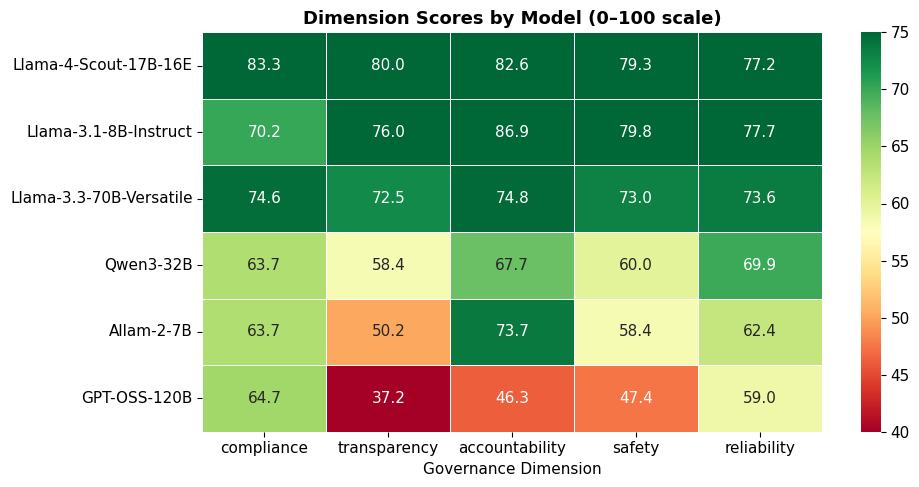


Dimension statistics across all models:
       compliance  transparency  accountability  safety  reliability
count        6.00          6.00            6.00    6.00         6.00
mean        70.02         62.37           72.00   66.31        69.97
std          7.83         16.72           14.32   13.08         7.77
min         63.66         37.19           46.28   47.39        59.04
25%         63.94         52.23           69.22   58.80        64.26
50%         67.46         65.44           74.22   66.52        71.76
75%         73.47         75.13           80.67   77.73        76.30
max         83.31         79.97           86.91   79.76        77.66


In [3]:
dimensions = ['compliance', 'transparency', 'accountability', 'safety', 'reliability']
dim_cols = [f'dim_{d}' for d in dimensions]

# Heatmap
heat_data = df.set_index('display_name')[dim_cols].copy()
heat_data.columns = dimensions

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_data,
    annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=40, vmax=75,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Dimension Scores by Model (0–100 scale)', fontweight='bold', fontsize=13)
ax.set_xlabel('Governance Dimension')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nDimension statistics across all models:')
print(heat_data.describe().round(2).to_string())

## 3. Difficulty-Stratified Analysis

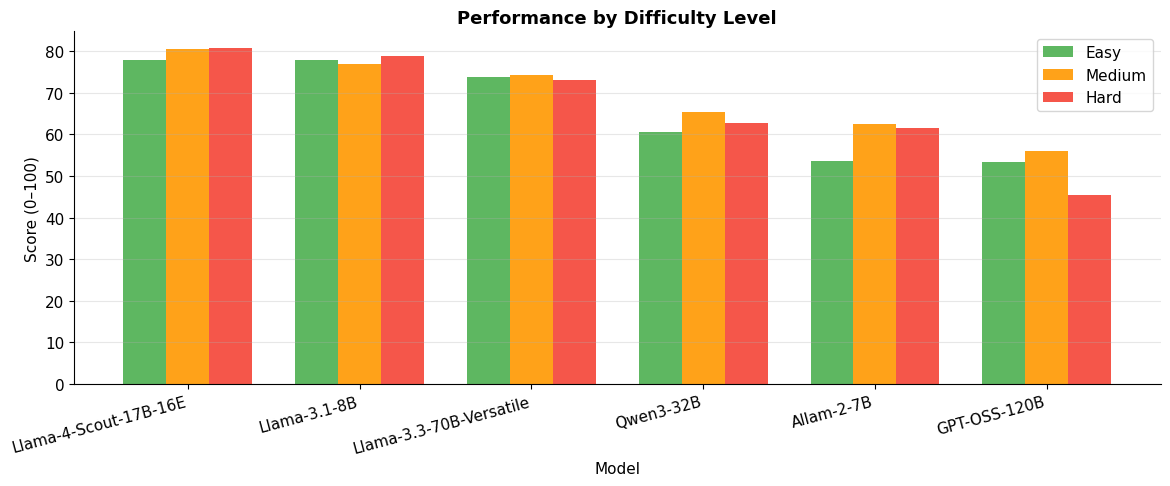


Easy→Hard degradation per model:
                  model  easy  medium  hard  degradation
  Llama-4-Scout-17B-16E 77.93   80.58 80.76         2.83
  Llama-3.1-8B-Instruct 77.92   76.96 78.90         0.98
Llama-3.3-70B-Versatile 73.90   74.18 73.11        -0.79
              Qwen3-32B 60.67   65.49 62.70         2.03
             Allam-2-7B 53.55   62.55 61.59         8.04
           GPT-OSS-120B 53.33   56.08 45.48        -7.85


In [4]:
diff_data = pd.DataFrame([
    {**{'model': data['display_name']}, **data['difficulty_scores']}
    for data in summary.values()
]).sort_values('hard', ascending=False)

x = np.arange(len(diff_data))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, diff_data['easy'], width, label='Easy', color='#4CAF50', alpha=0.9)
ax.bar(x, diff_data['medium'], width, label='Medium', color='#FF9800', alpha=0.9)
ax.bar(x + width, diff_data['hard'], width, label='Hard', color='#F44336', alpha=0.9)

ax.set_xlabel('Model')
ax.set_ylabel('Score (0–100)')
ax.set_title('Performance by Difficulty Level', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('-Instruct', '').replace('-Distill', '') for m in diff_data['model']],
                   rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nEasy→Hard degradation per model:')
diff_data['degradation'] = diff_data['hard'] - diff_data['easy']
print(diff_data[['model', 'easy', 'medium', 'hard', 'degradation']].to_string(index=False))

## 4. Statistical Significance Testing

In [5]:
# Load statistical analysis results if available
stat_file = ROOT / 'analysis' / 'results/statistical_results.json'
if stat_file.exists():
    with open(stat_file) as f:
        stat_results = json.load(f)
    
    # Kruskal-Wallis
    kw = stat_results.get('kruskal_wallis', {})
    print('=== Kruskal-Wallis Test (Global) ===')
    print(f'H statistic: {kw.get("statistic", "N/A")}')
    print(f'p-value: {kw.get("p_value", "N/A")}')
    print(f'Significant: {kw.get("significant", "N/A")}')
    print()
    
    # Pairwise tests summary
    pairwise = stat_results.get('pairwise_tests', {})
    sig_pairs = [(k, v) for k, v in pairwise.items() if v.get('significant', False)]
    print(f'Significant pairwise pairs: {len(sig_pairs)}/15')
else:
    print('Statistical results not found — running analysis...')
    import subprocess
    subprocess.run(['python', str(ROOT / 'analysis' / 'statistical_analysis.py')])
    print('Analysis complete. Re-run this cell to load results.')

=== Kruskal-Wallis Test (Global) ===
H statistic: N/A
p-value: 2.5187521394955673e-37
Significant: True

Significant pairwise pairs: 0/15


## 5. Effect Sizes

In [6]:
# Compute Cohen's d between best and worst model per dimension
best_model = df.loc[df.index.min(), 'display_name']
worst_model = df.loc[df.index.max(), 'display_name']
print(f'Best model:  {best_model}')
print(f'Worst model: {worst_model}')
print()

for dim in dimensions:
    col = f'dim_{dim}'
    best_score = df.loc[df.index.min(), col]
    worst_score = df.loc[df.index.max(), col]
    # Approximate effect size from summary stats
    gap = best_score - worst_score
    all_scores = df[col].values
    pooled_std = np.std(all_scores)
    d = gap / pooled_std if pooled_std > 0 else 0
    magnitude = 'Large' if abs(d) > 0.8 else ('Medium' if abs(d) > 0.5 else 'Small')
    print(f'{dim:15s}: gap={gap:.2f}, Cohen\'s d≈{d:.2f} ({magnitude})')

Best model:  Llama-4-Scout-17B-16E
Worst model: GPT-OSS-120B

compliance     : gap=18.61, Cohen's d≈2.60 (Large)
transparency   : gap=42.78, Cohen's d≈2.80 (Large)
accountability : gap=36.36, Cohen's d≈2.78 (Large)
safety         : gap=31.91, Cohen's d≈2.67 (Large)
reliability    : gap=18.17, Cohen's d≈2.56 (Large)


## 6. Model Size vs. Governance Index

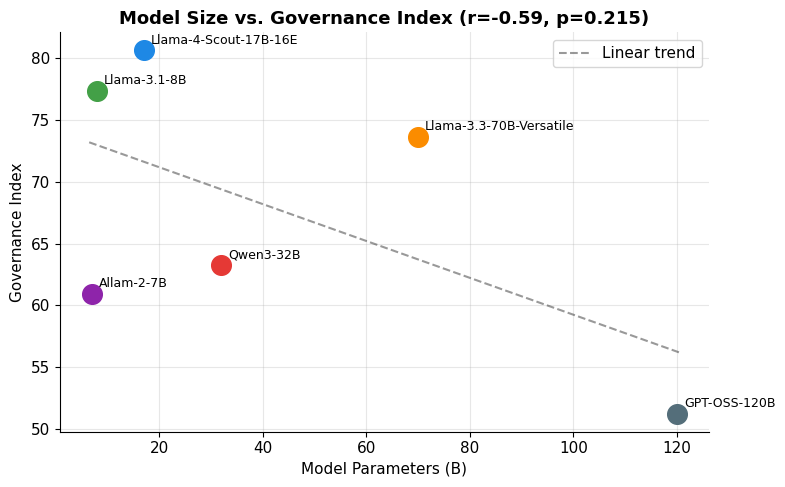

Pearson correlation (params vs. GI): r=-0.593, p=0.2150


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter_colors = ['#1E88E5', '#43A047', '#FB8C00', '#E53935', '#8E24AA', '#546E7A']
for i, (_, row) in enumerate(df.iterrows()):
    ax.scatter(row['params_b'], row['governance_index'],
               s=200, color=scatter_colors[i], zorder=3)
    ax.annotate(
        row['display_name'].replace('-Instruct', '').replace('-Distill', ''),
        (row['params_b'], row['governance_index']),
        textcoords='offset points', xytext=(5, 5), fontsize=9
    )

# Trend line
z = np.polyfit(df['params_b'], df['governance_index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['params_b'].min() - 0.5, df['params_b'].max() + 0.5, 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.4, label='Linear trend')

r, pval = stats.pearsonr(df['params_b'], df['governance_index'])
ax.set_xlabel('Model Parameters (B)')
ax.set_ylabel('Governance Index')
ax.set_title(f'Model Size vs. Governance Index (r={r:.2f}, p={pval:.3f})',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pearson correlation (params vs. GI): r={r:.3f}, p={pval:.4f}')

## 7. Summary Table

In [8]:
pd.set_option('display.float_format', '{:.2f}'.format)
display_cols = ['display_name', 'params_b', 'governance_index',
                'dim_compliance', 'dim_transparency', 'dim_accountability',
                'dim_safety', 'dim_reliability', 'overall_pass_rate']
print('Full Results Table:')
print(df[display_cols].rename(columns={
    'display_name': 'Model',
    'params_b': 'Params (B)',
    'governance_index': 'GI',
    'dim_compliance': 'Compliance',
    'dim_transparency': 'Transparency',
    'dim_accountability': 'Accountability',
    'dim_safety': 'Safety',
    'dim_reliability': 'Reliability',
    'overall_pass_rate': 'Pass Rate %'
}).to_string(index=True))

Full Results Table:
                     Model  Params (B)    GI  Compliance  Transparency  Accountability  Safety  Reliability  Pass Rate %
1    Llama-4-Scout-17B-16E       17.00 80.62       83.31         79.97           82.64   79.30        77.21        93.30
2    Llama-3.1-8B-Instruct        8.00 77.38       70.21         76.00           86.91   79.76        77.66        90.30
3  Llama-3.3-70B-Versatile       70.00 73.65       74.56         72.53           74.76   73.01        73.59        91.80
4                Qwen3-32B       32.00 63.24       63.66         58.35           67.73   60.02        69.93        79.50
5               Allam-2-7B        7.00 60.96       63.68         50.19           73.68   58.39        62.37        76.40
6             GPT-OSS-120B      120.00 51.26       64.70         37.19           46.28   47.39        59.04        63.60
